#TASK 6 — Statistical Analysis

##Importing Libraries

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway

##Loading Dataset

In [13]:
df = pd.read_csv('/content/patient_feedback_featured.csv')

print(df.head())

           Theme                                        Feedback  Sentiment  \
0      discharge          discharge instructions were very clear          1   
1  communication  i felt the doctor used too much medical jargon          1   
2     medication  i appreciated the reminders about my medicines          1   
3      discharge   instructions after discharge were not helpful          0   
4      discharge   instructions after discharge were not helpful          0   

   Satisfaction  Readmission  Feedback_Length  Word_Count  \
0             4            1               38           5   
1             5            0               46           9   
2             4            0               46           7   
3             1            1               45           6   
4             2            1               45           6   

   Theme_Sentiment_Ratio     about  admitted  ...     very  wait  waiting  \
0               0.500000  0.000000       0.0  ...  0.50346   0.0      0.0   
1   

## Correlation Analysis

Correlation is a statistical measure that expresses the extent to which two variables are linearly related (meaning they change together at a constant rate). It's a common tool for describing simple relationships without making a statement about cause and effect.

We will calculate the Pearson correlation coefficient, which ranges from -1 to 1:
- **1**: Perfect positive correlation (as one variable increases, the other increases proportionally).
- **-1**: Perfect negative correlation (as one variable increases, the other decreases proportionally).
- **0**: No linear correlation.

Correlation Matrix (first 5x5):
                 Sentiment  Satisfaction  Readmission  Feedback_Length  \
Sentiment         1.000000      0.877984    -0.010638        -0.092405   
Satisfaction      0.877984      1.000000    -0.013132        -0.080505   
Readmission      -0.010638     -0.013132     1.000000         0.002755   
Feedback_Length  -0.092405     -0.080505     0.002755         1.000000   
Word_Count       -0.088367     -0.074882     0.008603         0.729192   

                 Word_Count  
Sentiment         -0.088367  
Satisfaction      -0.074882  
Readmission        0.008603  
Feedback_Length    0.729192  
Word_Count         1.000000  


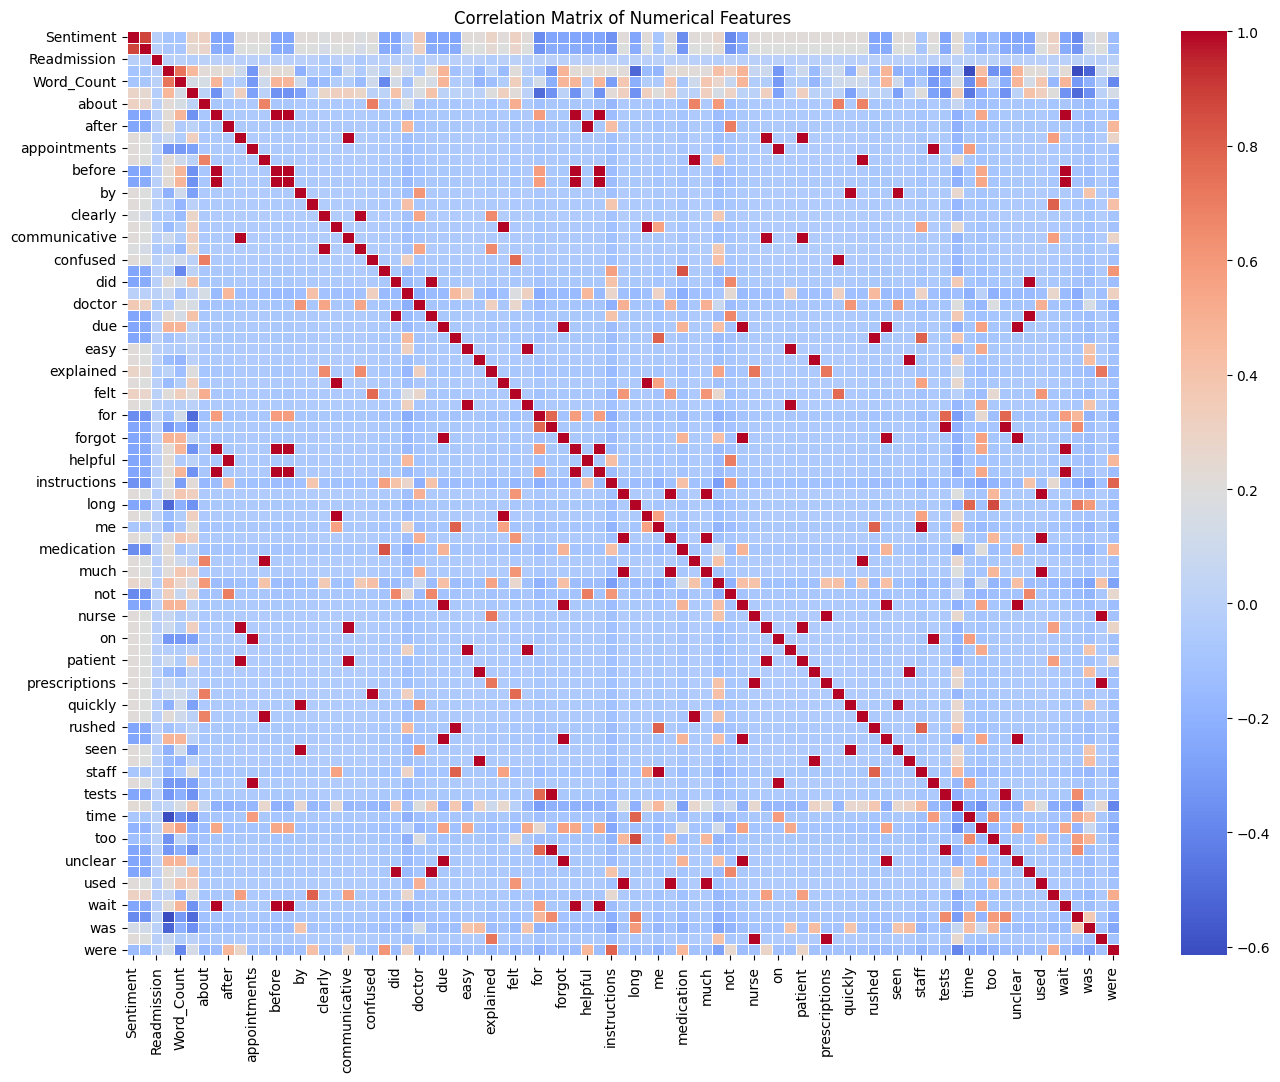

In [14]:
# Select only numerical columns for correlation analysis
numerical_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Display the correlation matrix (first few rows/columns for brevity)
print("Correlation Matrix (first 5x5):")
print(correlation_matrix.head().iloc[:, :5])

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

The heatmap visually represents the correlation coefficients. Red shades indicate positive correlations, while blue shades indicate negative correlations. The intensity of the color corresponds to the strength of the correlation (darker colors mean stronger relationships).

If the `annot=True` parameter was used in `sns.heatmap()`, the numerical correlation values would also be displayed on the heatmap itself. For a large number of features, it's often better to start with `annot=False` to get a general overview, and then zoom into specific correlations if needed.

## Hypothesis Testing

Hypothesis testing is a statistical method used to make inferences about a population parameter (e.g., mean, proportion, variance) based on sample data. It involves formulating a null hypothesis (H0) and an alternative hypothesis (Ha), collecting data, and using statistical tests to determine whether there is enough evidence to reject the null hypothesis.

### Chi-Square Test

The Chi-Square ($\\chi^2$) test is a non-parametric statistical test used to determine if there is a significant association between two categorical variables. It compares the observed frequencies in a contingency table with the expected frequencies if there were no association between the variables.

**Null Hypothesis (H0)**: There is no association between the two categorical variables.
**Alternative Hypothesis (Ha)**: There is a significant association between the two categorical variables.

The test calculates a $\\chi^2$ statistic and a p-value. If the p-value is less than a chosen significance level (commonly 0.05), we reject the null hypothesis and conclude that there is a significant association between the variables.

In [15]:
# Create a contingency table between 'Theme' and 'Sentiment'
contingency_table = pd.crosstab(df['Theme'], df['Sentiment'])

print("Contingency Table (Theme vs. Sentiment):")
print(contingency_table)

# Perform the Chi-Square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-Square Statistic: {chi2:.2f}")
print(f"P-value: {p_value:.3f}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies:\n", pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns))

Contingency Table (Theme vs. Sentiment):
Sentiment       0   1
Theme                
communication   6  15
discharge      12  12
medication     12  12
wait_time      18   8

Chi-Square Statistic: 7.69
P-value: 0.053
Degrees of Freedom: 3
Expected Frequencies:
 Sentiment              0          1
Theme                              
communication  10.610526  10.389474
discharge      12.126316  11.873684
medication     12.126316  11.873684
wait_time      13.136842  12.863158


### Interpreting the Chi-Square Test Results

-   **Chi-Square Statistic**: This value measures the discrepancy between the observed frequencies and the expected frequencies. A larger chi-square statistic suggests a greater difference from what would be expected if there were no association.
-   **P-value**: This is the probability of observing a chi-square statistic as extreme as, or more extreme than, the one calculated, assuming the null hypothesis (no association) is true.

    -   If the p-value is less than the chosen significance level (e.g., 0.05), we reject the null hypothesis. This means there is statistically significant evidence to conclude that there is an association between the 'Theme' of the feedback and its 'Sentiment'.
    -   If the p-value is greater than the significance level, we fail to reject the null hypothesis. This means there is not enough evidence to conclude a significant association.

By examining the contingency table and the expected frequencies, you can see which specific categories contribute most to the observed differences.

## ANOVA (Analysis of Variance)

ANOVA is a statistical test used to compare the means of three or more groups to see if at least one group mean is significantly different from the others. It is commonly used to analyze the differences among group means in a sample.

**Null Hypothesis (H0)**: The means of all groups are equal (e.g., there is no difference in average satisfaction across different themes).
**Alternative Hypothesis (Ha)**: At least one group mean is different from the others (e.g., average satisfaction differs for at least one theme).

We will use the F-statistic and p-value to interpret the results. A low p-value (typically < 0.05) indicates that we can reject the null hypothesis, suggesting a significant difference between group means.

In [16]:
# Prepare data for ANOVA: Group 'Satisfaction' by 'Theme'
themes = df['Theme'].unique()
anova_data = [df['Satisfaction'][df['Theme'] == theme] for theme in themes]

# Perform one-way ANOVA
f_statistic, p_value = f_oneway(*anova_data)

print(f"ANOVA F-statistic: {f_statistic:.2f}")
print(f"ANOVA P-value: {p_value:.3f}")

ANOVA F-statistic: 1.94
ANOVA P-value: 0.129


### Interpreting the ANOVA Results

-   **F-statistic**: This value represents the ratio of the variance between the groups to the variance within the groups. A larger F-statistic suggests that the differences between group means are greater than the differences within the groups.
-   **P-value**: This is the probability of obtaining an F-statistic as extreme as, or more extreme than, the one calculated, assuming the null hypothesis (all group means are equal) is true.

    -   If the p-value is less than the chosen significance level (e.g., 0.05), we reject the null hypothesis. This means there is statistically significant evidence that the average 'Satisfaction' is different for at least one 'Theme' category.
    -   If the p-value is greater than the significance level, we fail to reject the null hypothesis. This means there is not enough evidence to conclude a significant difference in average 'Satisfaction' across the different 'Themes'.